In [1]:
!pip install osmnx contextily mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 2.2 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

print("osmnx     ", ox.__version__)
print("geopandas ", gpd.__version__)
print("networkx  ", nx.__version__)

osmnx      2.1.1
geopandas  1.1.4
networkx   3.6.1


Loaded 3,075 intersections and 6,449 road segments


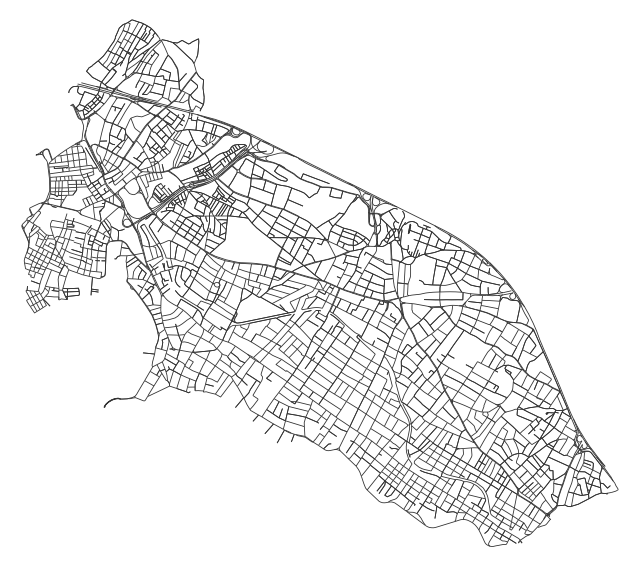

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
# Your study area — change the district name to any place you like
place = "Kadıköy, İstanbul, Turkey"

# Download the drivable street network for that area from OpenStreetMap
G = ox.graph_from_place(place, network_type="drive")

# How much did we get?
print(f"Loaded {len(G.nodes):,} intersections and {len(G.edges):,} road segments")

# Draw it
ox.plot_graph(G, node_size=0, edge_color="#333333",
              edge_linewidth=0.6, bgcolor="white")

In [4]:
# In OpenStreetMap, every feature carries "tags" — key=value labels.
# A café is tagged  amenity=cafe.  That's what we ask for:
tags = {"amenity": "cafe"}

# Download every café inside the same study area
cafes = ox.features_from_place(place, tags)

print(f"Found {len(cafes)} cafés in {place}")
cafes[["name"]].head(20)

Found 745 cafés in Kadıköy, İstanbul, Turkey


name
element id                                 
node    1394878662    Beyaz Fırın - Erenköy
        1394941165         Baylan Pastanesi
        1394975639  Ali Muhiddin Hacı Bekir
        1757629731                     Mado
        1834383973                     Mado
        1867001075          Pelit Pastanesi
        1915178434     uğur cafe caybahcesi
        1920280837          Hasret Çayocağı
        1921444709                Starbucks
        2129082395                Starbucks
        2277774144                 Cafe Mod
        2433366998               Caffè Nero
        2433367013        Vitavien Bahariye
        2433367014                Starbucks
        2433367015                Starbucks
        2437124304                      NaN
        2437124306                      NaN
        2437124308                      NaN
        2437124309                      NaN
        2437124310                 Midpoint

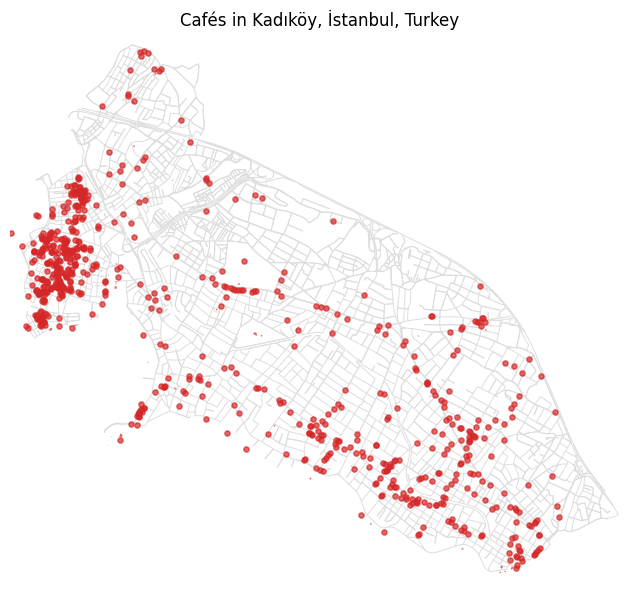

In [5]:

# Streets in light grey, cafés as red dots on top
fig, ax = ox.plot_graph(
    G, node_size=0, edge_color="#dddddd", edge_linewidth=0.7,
    bgcolor="white", show=False, close=False
)
cafes.plot(ax=ax, color="#d62728", markersize=14, alpha=0.7)
ax.set_title(f"Cafés in {place}", fontsize=12)
plt.show()

In [6]:
# Get Kadıköy's boundary as a polygon
area = ox.geocode_to_gdf(place)

# Project the street network to metres (OSMnx auto-picks the right zone for Istanbul)
Gp = ox.project_graph(G)
crs_m = Gp.graph["crs"]           # the metric coordinate system it chose
print("Now working in:", crs_m)

# Put the boundary and cafés into that SAME metric system
area_m  = area.to_crs(crs_m)
cafes_m = cafes.to_crs(crs_m)

Now working in: EPSG:32635


In [7]:
print(cafes_m.geom_type.value_counts())        # see the mix

# Reduce every café to one representative point (guaranteed to sit inside its shape)
cafes_pt = cafes_m.copy()
cafes_pt["geometry"] = cafes_m.geometry.representative_point()

Point      704
Polygon     41
Name: count, dtype: int64


626 candidate locations to evaluate


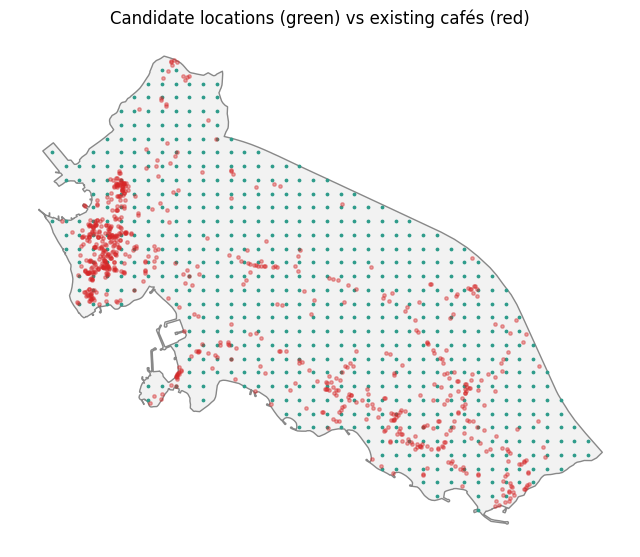

In [8]:
import numpy as np
from shapely.geometry import Point
import geopandas as gpd

minx, miny, maxx, maxy = area_m.total_bounds   # the bounding box, in metres
STEP = 200                                      # a candidate every 200 m

# Lay down a regular grid of points across the bounding box
pts = [Point(x, y) for x in np.arange(minx, maxx, STEP)
                   for y in np.arange(miny, maxy, STEP)]
grid = gpd.GeoDataFrame(geometry=pts, crs=crs_m)

# Keep only the ones that fall inside Kadıköy's real boundary
boundary = area_m.geometry.iloc[0]
grid = grid[grid.within(boundary)].reset_index(drop=True)
print(f"{len(grid)} candidate locations to evaluate")

# See the canvas: boundary, candidate grid (green), existing cafés (red)
ax = area_m.plot(color="#f2f2f2", edgecolor="#888", figsize=(8, 8))
grid.plot(ax=ax, color="#2f9c8b", markersize=3)
cafes_pt.plot(ax=ax, color="#d62728", markersize=6, alpha=0.4)
ax.set_title("Candidate locations (green) vs existing cafés (red)")
ax.set_axis_off()

In [9]:
from scipy.spatial import cKDTree

# Pull coordinates into plain (x, y) arrays, in metres
cafe_xy = np.column_stack([cafes_pt.geometry.x, cafes_pt.geometry.y])
grid_xy = np.column_stack([grid.geometry.x, grid.geometry.y])

# A KD-tree: a structure that finds nearest neighbours very fast
tree = cKDTree(cafe_xy)

In [10]:
# For each candidate, find its 10 nearest cafés and their distances (in metres)
DECAY = 300   # metres — the "half-life" of competition; smaller = only very close rivals matter
dists, _ = tree.query(grid_xy, k=10)

# Exponential decay: a café at distance d contributes exp(-d / DECAY)
#   right next door (d≈0) -> ~1.0 (full pressure)
#   one DECAY away         -> ~0.37
#   far away               -> ~0
pressure = np.exp(-dists / DECAY).sum(axis=1)

grid["competition_pressure"] = pressure
print(grid["competition_pressure"].describe())

count    626.000000
mean       3.680128
std        1.780150
min        0.304746
25%        2.378290
50%        3.496225
75%        4.763346
max        8.622222
Name: competition_pressure, dtype: float64


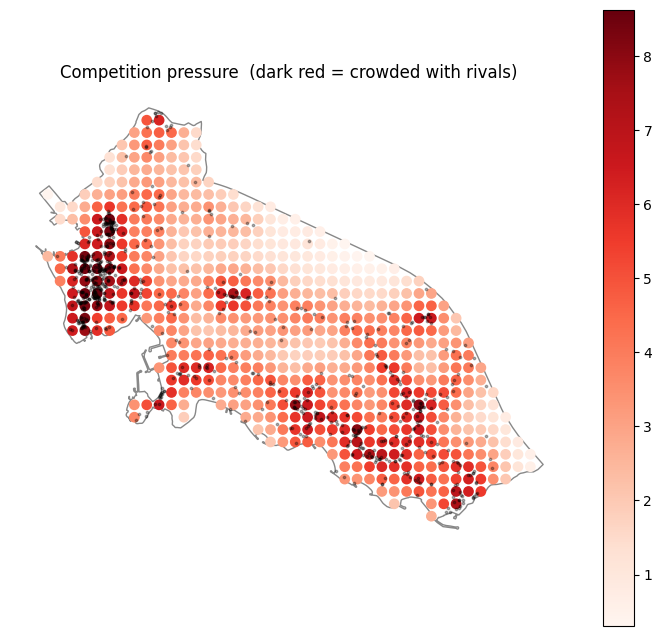

In [11]:
ax = area_m.plot(color="white", edgecolor="#888", figsize=(9, 8))
grid.plot(ax=ax, column="competition_pressure", cmap="Reds",
          markersize=45, legend=True)
cafes_pt.plot(ax=ax, color="black", markersize=3, alpha=0.3)
ax.set_title("Competition pressure  (dark red = crowded with rivals)")
ax.set_axis_off()

In [12]:
# "Signs of life" — everyday places that indicate people & footfall.
# (Deliberately NOT cafés — that's competition, a separate thing.)
poi_tags = {
    "shop": True,                              # any shop
    "amenity": ["restaurant", "school", "bank",
                "pharmacy", "marketplace"],     # everyday services
    "public_transport": True                    # stops & stations
}

pois = ox.features_from_place(place, poi_tags)
pois_m = pois.to_crs(crs_m)
pois_m["geometry"] = pois_m.geometry.representative_point()
print(f"Pulled {len(pois_m):,} points of interest as a demand proxy")

Pulled 4,300 points of interest as a demand proxy


In [13]:
poi_xy = np.column_stack([pois_m.geometry.x, pois_m.geometry.y])
poi_tree = cKDTree(poi_xy)

# How many "signs of life" sit within a short walk of each candidate?
CATCHMENT = 400   # metres — roughly a 5-minute walk = a café's realistic catchment
counts = poi_tree.query_ball_point(grid_xy, r=CATCHMENT)
grid["demand"] = [len(c) for c in counts]

print(grid["demand"].describe())

count    626.000000
mean      82.234824
std       74.150404
min        0.000000
25%       37.000000
50%       64.000000
75%      103.000000
max      531.000000
Name: demand, dtype: float64


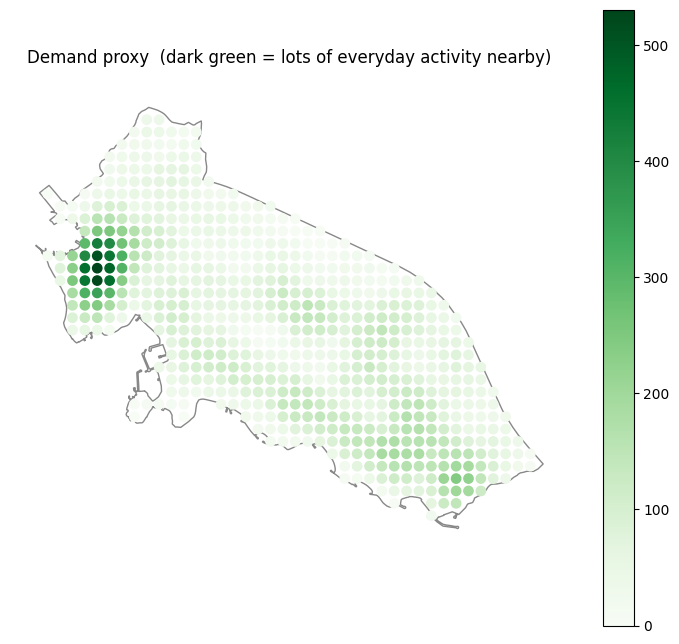

In [14]:
ax = area_m.plot(color="white", edgecolor="#888", figsize=(9, 8))
grid.plot(ax=ax, column="demand", cmap="Greens",
          markersize=45, legend=True)
ax.set_title("Demand proxy  (dark green = lots of everyday activity nearby)")
ax.set_axis_off()

In [15]:
def normalize(series):
    """Rescale any layer to a 0-1 range by percentile rank.
       Rank-based (not min-max) so a few extreme values don't dominate."""
    return series.rank(pct=True)

grid["demand_n"]      = normalize(grid["demand"])
grid["low_comp_n"]    = normalize(-grid["competition_pressure"])   # NOTE the minus

In [16]:
# Weights must sum to 1. THESE ARE A BUSINESS DECISION, not a mathematical truth.
W_DEMAND = 0.55
W_LOWCOMP = 0.45

grid["suitability"] = (W_DEMAND  * grid["demand_n"]
                     + W_LOWCOMP * grid["low_comp_n"])

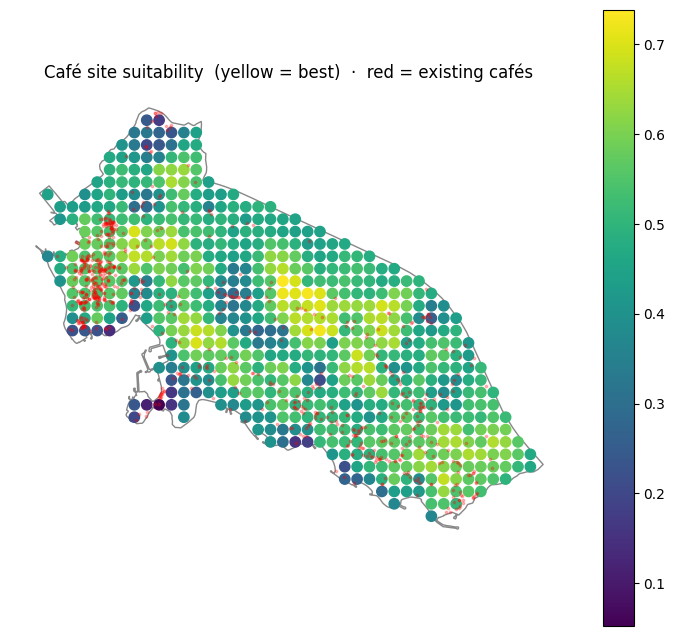

In [17]:
ax = area_m.plot(color="white", edgecolor="#888", figsize=(9, 8))
grid.plot(ax=ax, column="suitability", cmap="viridis",
          markersize=55, legend=True)
cafes_pt.plot(ax=ax, color="red", markersize=3, alpha=0.25)
ax.set_title("Café site suitability  (yellow = best)  ·  red = existing cafés")
ax.set_axis_off()
plt.savefig("suitability_map.png", dpi=200, bbox_inches="tight")

In [18]:
# Rank all candidates best-first
ranked = grid.sort_values("suitability", ascending=False).reset_index(drop=True)

SPACING = 500      # metres — recommended sites must be at least this far apart
chosen = []

for _, cand in ranked.iterrows():
    # keep this candidate only if it's far enough from all already-chosen ones
    if all(cand.geometry.distance(c.geometry) > SPACING for c in chosen):
        chosen.append(cand)
    if len(chosen) == 5:      # we want a top-5 shortlist
        break

top = gpd.GeoDataFrame(chosen, crs=crs_m)
top["rank"] = range(1, len(top) + 1)
top[["rank", "suitability", "demand", "competition_pressure"]]

,rank,suitability,demand,competition_pressure
0,1,0.738259,101,2.424552
2,2,0.723442,113,2.901489
6,3,0.702396,87,2.301640
7,4,0.697684,168,3.891364
8,5,0.696845,103,2.926557


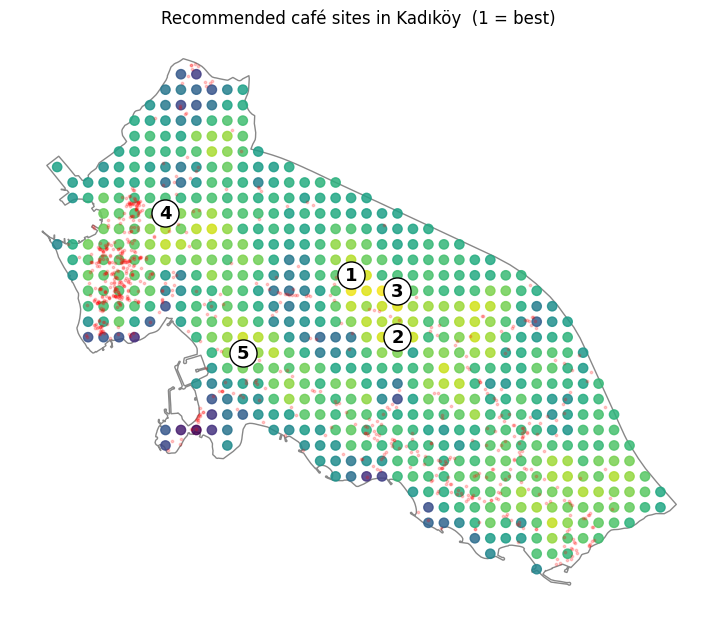

In [19]:
ax = area_m.plot(color="white", edgecolor="#888", figsize=(9, 8))
grid.plot(ax=ax, column="suitability", cmap="viridis",
          markersize=45, alpha=0.85)
cafes_pt.plot(ax=ax, color="red", markersize=3, alpha=0.2)

# Recommended sites as big numbered markers
top.plot(ax=ax, color="white", edgecolor="black", markersize=380, zorder=5)
for _, r in top.iterrows():
    ax.annotate(int(r["rank"]), (r.geometry.x, r.geometry.y),
                ha="center", va="center", fontsize=13,
                fontweight="bold", zorder=6)

ax.set_title("Recommended café sites in Kadıköy  (1 = best)")
ax.set_axis_off()

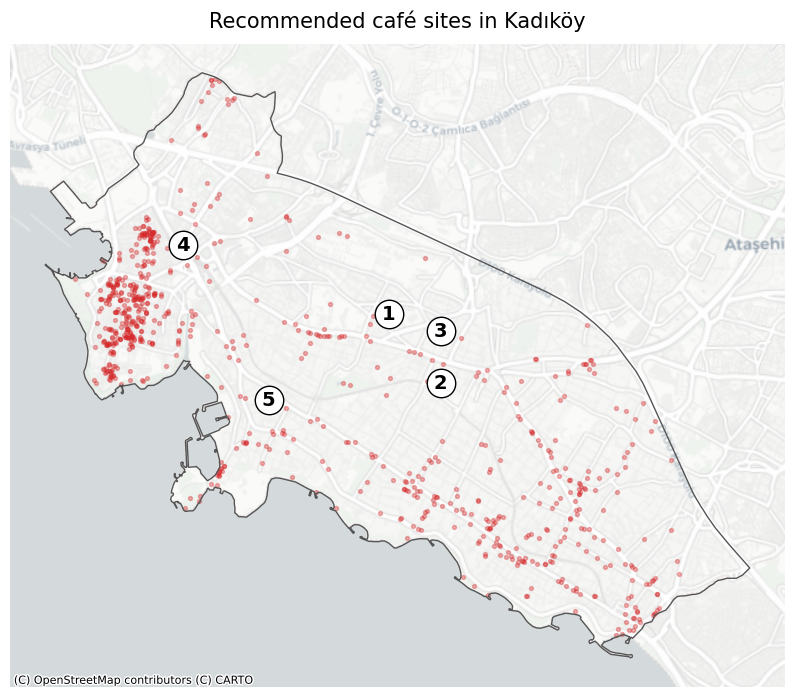

In [20]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

# district outline (facecolor none, so the basemap shows through) — also sets the frame
area_m.boundary.plot(ax=ax, color="#555555", linewidth=1)

# existing cafés, faded, for context
cafes_pt.plot(ax=ax, color="#d62728", markersize=8, alpha=0.35)

# the 5 recommended sites as numbered white pins
top.plot(ax=ax, color="white", edgecolor="black", markersize=420, zorder=5)
for _, r in top.iterrows():
    ax.annotate(int(r["rank"]), (r.geometry.x, r.geometry.y),
                ha="center", va="center", fontsize=14, fontweight="bold", zorder=6)

# drop a REAL street map underneath, warped to our metre-based CRS
ctx.add_basemap(ax, crs=top.crs, source=ctx.providers.CartoDB.Positron)

ax.set_title("Recommended café sites in Kadıköy", fontsize=15, pad=12)
ax.set_axis_off()
plt.savefig("sites_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 7.8 MB/s eta 0:00:00


In [23]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

# --- Title ---
pdf.set_font("Helvetica", "B", 20)
pdf.set_x(pdf.l_margin)                        # force cursor to left margin
pdf.multi_cell(0, 10, "Where Should a New Cafe Open in Kadikoy?")
pdf.set_font("Helvetica", "", 12)
pdf.set_text_color(90, 90, 90)
pdf.set_x(pdf.l_margin)
pdf.multi_cell(0, 7, "A data-driven site-selection analysis  |  Istanbul, Turkey")
pdf.ln(4)

# --- The brief ---
pdf.set_text_color(0, 0, 0)
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "The question", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 6,
    "Kadikoy already has 744 cafes. The goal was not to find empty space, "
    "but to find unmet demand: locations with real foot traffic that existing "
    "cafes have not yet captured. I scored 626 candidate sites on live "
    "OpenStreetMap data across two signals - local demand and competition.")
pdf.ln(3)

# --- The recommendation map ---
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "Recommended sites", ln=True)
pdf.image("sites_map.png", w=180)     # w=180mm fits the page width with margins
pdf.ln(3)

# --- The findings ---
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "What the model found", ln=True)
pdf.set_font("Helvetica", "", 11)
findings = (
    "- The strongest sites sit just inland of the saturated Moda waterfront - "
    "enough activity to sustain a cafe, with fewer rivals than the coast.\n"
    "- Site 1 is the balanced pick: solid demand, below-average competition.\n"
    "- Site 4 has the district's highest footfall, but more competition - "
    "the choice for an operator confident they can compete on quality.\n"
    "- Site 3 is the lowest-risk option: fewer customers, but the emptiest market."
)
pdf.multi_cell(0, 6, findings)
pdf.ln(3)

# --- The opportunity surface (second map) ---
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "The opportunity surface", ln=True)
pdf.image("suitability_map.png", x=10, w=190)
pdf.ln(3)

# --- Method & honesty note ---
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "Method", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 6,
    "Demand was estimated from everyday activity (shops, transit, services) "
    "within a 5-minute walk - a proxy used because open census data was not "
    "available at this resolution. Competition was modeled as distance-decay "
    "pressure from existing cafes. Scores were normalized by percentile rank "
    "and weighted 55% demand / 45% low-competition. Tools: Python, OSMnx, "
    "GeoPandas, NetworkX.")
pdf.ln(4)

# --- Contact ---
pdf.set_font("Helvetica", "B", 11)
pdf.set_text_color(15, 92, 77)
pdf.multi_cell(0, 6,
    "Have a market in mind? I can run this on any city or business type.\n"
    "azeem.patil18@gmail.com  |  your-portfolio-link")

pdf.output("Kadikoy_Cafe_Site_Selection.pdf")
print("Saved! Find it in the file panel on the left, then download it.")

/tmp/ipykernel_651/3604786586.py:19: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "The question", ln=True)
/tmp/ipykernel_651/3604786586.py:30: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "Recommended sites", ln=True)


Saved! Find it in the file panel on the left, then download it.


/tmp/ipykernel_651/3604786586.py:36: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "What the model found", ln=True)
/tmp/ipykernel_651/3604786586.py:51: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "The opportunity surface", ln=True)
/tmp/ipykernel_651/3604786586.py:57: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "Method", ln=True)
